In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models

In [4]:
import os

base_path = "/kaggle/input/datasets/waseemalastal/breakhis-breast-cancer-histopathological-dataset"

print(os.listdir(base_path))

path_200x = "/kaggle/input/datasets/waseemalastal/breakhis-breast-cancer-histopathological-dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_multiclasse/200X"

print(os.listdir(path_200x))

['BreakHis - Breast Cancer Histopathological Database']
['adenosis', 'lobular_carcinoma', 'phyllodes_tumor', 'mucinous_carcinoma', 'ductal_carcinoma', 'papillary_carcinoma', 'tubular_adenoma', 'fibroadenoma']


In [5]:
base_path = "/kaggle/input/datasets/waseemalastal/breakhis-breast-cancer-histopathological-dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_multiclasse"

for mag in os.listdir(base_path):
    mag_path = os.path.join(base_path, mag)
    if os.path.isdir(mag_path):
        print(f"\nMagnification: {mag}")
        print("Classes:", os.listdir(mag_path))


Magnification: 200X
Classes: ['adenosis', 'lobular_carcinoma', 'phyllodes_tumor', 'mucinous_carcinoma', 'ductal_carcinoma', 'papillary_carcinoma', 'tubular_adenoma', 'fibroadenoma']

Magnification: 400X
Classes: ['adenosis', 'lobular_carcinoma', 'phyllodes_tumor', 'mucinous_carcinoma', 'ductal_carcinoma', 'papillary_carcinoma', 'tubular_adenoma', 'fibroadenoma']

Magnification: 40X
Classes: ['adenosis', 'lobular_carcinoma', 'phyllodes_tumor', 'mucinous_carcinoma', 'ductal_carcinoma', 'papillary_carcinoma', 'tubular_adenoma', 'fibroadenoma']

Magnification: 100X
Classes: ['adenosis', 'lobular_carcinoma', 'phyllodes_tumor', 'mucinous_carcinoma', 'ductal_carcinoma', 'papillary_carcinoma', 'tubular_adenoma', 'fibroadenoma']


In [20]:
import os
from collections import Counter

base_path = "/kaggle/input/datasets/waseemalastal/breakhis-breast-cancer-histopathological-dataset/BreakHis - Breast Cancer Histopathological Database/dataset_cancer_v1/dataset_cancer_v1/classificacao_multiclasse"

# Define benign classes manually
benign_classes = [
    "adenosis",
    "fibroadenoma",
    "phyllodes_tumor",
    "tubular_adenoma"
]

image_paths = []
labels = []

for mag in os.listdir(base_path):
    mag_path = os.path.join(base_path, mag)

    if os.path.isdir(mag_path):
        for cls in os.listdir(mag_path):
            cls_path = os.path.join(mag_path, cls)

            if os.path.isdir(cls_path):

                # Correct binary mapping
                if cls in benign_classes:
                    label = 0   # Benign
                else:
                    label = 1   # Malignant

                for img_name in os.listdir(cls_path):
                    img_path = os.path.join(cls_path, img_name)
                    image_paths.append(img_path)
                    labels.append(label)

print("Total images:", len(image_paths))
print("Class distribution:", Counter(labels))

Total images: 7909
Class distribution: Counter({1: 5429, 0: 2480})


In [7]:

IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [8]:
class BreakHisDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

In [10]:
full_dataset = BreakHisDataset(image_paths, labels, transform=None)

In [25]:
from sklearn.model_selection import train_test_split

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

print("Train size:", len(train_paths))

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print("Validation size:", len(val_paths))
print("Test size:", len(test_paths))

from collections import Counter

print("Train distribution:", Counter(train_labels))
print("Val distribution:", Counter(val_labels))
print("Test distribution:", Counter(test_labels))

Train size: 5536
Validation size: 1186
Test size: 1187
Train distribution: Counter({1: 3800, 0: 1736})
Val distribution: Counter({1: 814, 0: 372})
Test distribution: Counter({1: 815, 0: 372})


In [26]:
train_dataset = BreakHisDataset(train_paths, train_labels, transform=train_transforms)
val_dataset   = BreakHisDataset(val_paths, val_labels, transform=val_transforms)
test_dataset  = BreakHisDataset(test_paths, test_labels, transform=val_transforms)

In [27]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [16]:
models.efficientnet_b0(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 141MB/s] 


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [28]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

model = model.to(device)

In [30]:
for param in model.features.parameters():
    param.requires_grad = False

In [32]:
in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(in_features, 2)

model = model.to(device)

In [33]:
from collections import Counter

train_counts = Counter(train_labels)
print(train_counts)

total_samples = len(train_labels)

class_weights = torch.tensor([
    total_samples / train_counts[0],  # benign
    total_samples / train_counts[1]   # malignant
], dtype=torch.float32).to(device)

print("Class weights:", class_weights)

Counter({1: 3800, 0: 1736})
Class weights: tensor([3.1889, 1.4568], device='cuda:0')


In [35]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)

In [37]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch

EPOCHS = 40

best_val_acc = 0.0

for epoch in range(EPOCHS):

    # ===================== TRAIN =====================
    model.train()
    train_loss = 0.0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)


    # ===================== VALIDATION =====================
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)

    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Val F1-score: {val_f1:.4f}")
    print("-"*40)


    # ===================== SAVE BEST MODEL =====================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("🔥 Best model saved!\n")

Epoch [1/40]
Train Loss: 0.4801
Val Loss: 0.3854
Val Accuracy: 0.8347
Val F1-score: 0.8716
----------------------------------------
🔥 Best model saved!

Epoch [2/40]
Train Loss: 0.4404
Val Loss: 0.3686
Val Accuracy: 0.8179
Val F1-score: 0.8544
----------------------------------------
Epoch [3/40]
Train Loss: 0.4337
Val Loss: 0.3426
Val Accuracy: 0.8567
Val F1-score: 0.8900
----------------------------------------
🔥 Best model saved!

Epoch [4/40]
Train Loss: 0.4167
Val Loss: 0.3218
Val Accuracy: 0.8676
Val F1-score: 0.8990
----------------------------------------
🔥 Best model saved!

Epoch [5/40]
Train Loss: 0.4081
Val Loss: 0.3204
Val Accuracy: 0.8600
Val F1-score: 0.8929
----------------------------------------
Epoch [6/40]
Train Loss: 0.4078
Val Loss: 0.3234
Val Accuracy: 0.8474
Val F1-score: 0.8802
----------------------------------------
Epoch [7/40]
Train Loss: 0.4149
Val Loss: 0.3136
Val Accuracy: 0.8626
Val F1-score: 0.8952
----------------------------------------
Epoch [8/40]


In [38]:
model.load_state_dict(torch.load("best_model.pth"))

for param in model.features.parameters():
    param.requires_grad = True

In [39]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [40]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import torch

EPOCHS = 55

best_val_acc = 0.0

for epoch in range(EPOCHS):

    # ===================== TRAIN =====================
    model.train()
    train_loss = 0.0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    train_loss /= len(train_loader.dataset)


    # ===================== VALIDATION =====================
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader.dataset)

    val_acc = accuracy_score(all_labels, all_preds)
    val_f1 = f1_score(all_labels, all_preds)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Val F1-score: {val_f1:.4f}")
    print("-"*40)


    # ===================== SAVE BEST MODEL =====================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("🔥 Best model saved!\n")

Epoch [1/55]
Train Loss: 0.3890
Val Loss: 0.2509
Val Accuracy: 0.8895
Val F1-score: 0.9168
----------------------------------------
🔥 Best model saved!

Epoch [2/55]
Train Loss: 0.3354
Val Loss: 0.2316
Val Accuracy: 0.8971
Val F1-score: 0.9222
----------------------------------------
🔥 Best model saved!

Epoch [3/55]
Train Loss: 0.3013
Val Loss: 0.2154
Val Accuracy: 0.8971
Val F1-score: 0.9205
----------------------------------------
Epoch [4/55]
Train Loss: 0.2884
Val Loss: 0.1988
Val Accuracy: 0.9089
Val F1-score: 0.9303
----------------------------------------
🔥 Best model saved!

Epoch [5/55]
Train Loss: 0.2625
Val Loss: 0.1824
Val Accuracy: 0.9241
Val F1-score: 0.9432
----------------------------------------
🔥 Best model saved!

Epoch [6/55]
Train Loss: 0.2311
Val Loss: 0.1699
Val Accuracy: 0.9199
Val F1-score: 0.9391
----------------------------------------
Epoch [7/55]
Train Loss: 0.2304
Val Loss: 0.1605
Val Accuracy: 0.9300
Val F1-score: 0.9473
---------------------------------

In [41]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [42]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)

print("Test Accuracy:", test_acc)
print("Test F1-score:", test_f1)

Test Accuracy: 0.9755686604886268
Test F1-score: 0.9820655534941249


In [44]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, matthews_corrcoef, balanced_accuracy_score,
    roc_curve, precision_recall_curve
)

import numpy as np
import torch

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = torch.argmax(outputs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [45]:
cm = confusion_matrix(all_labels, all_preds)
TN, FP, FN, TP = cm.ravel()

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[364   8]
 [ 21 794]]


In [46]:
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
sensitivity = recall_score(all_labels, all_preds)
specificity = TN / (TN + FP)
f1 = f1_score(all_labels, all_preds)
auroc = roc_auc_score(all_labels, all_probs)
auprc = average_precision_score(all_labels, all_probs)
mcc = matthews_corrcoef(all_labels, all_preds)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)

In [47]:
print("\n===== Test Performance Metrics =====")
print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Sensitivity         : {sensitivity:.4f}")
print(f"Specificity         : {specificity:.4f}")
print(f"F1-score            : {f1:.4f}")
print(f"AUROC               : {auroc:.4f}")
print(f"AUPRC               : {auprc:.4f}")
print(f"MCC                 : {mcc:.4f}")
print(f"Balanced Accuracy   : {balanced_acc:.4f}")


===== Test Performance Metrics =====
Accuracy            : 0.9756
Precision           : 0.9900
Sensitivity         : 0.9742
Specificity         : 0.9785
F1-score            : 0.9821
AUROC               : 0.9980
AUPRC               : 0.9991
MCC                 : 0.9441
Balanced Accuracy   : 0.9764


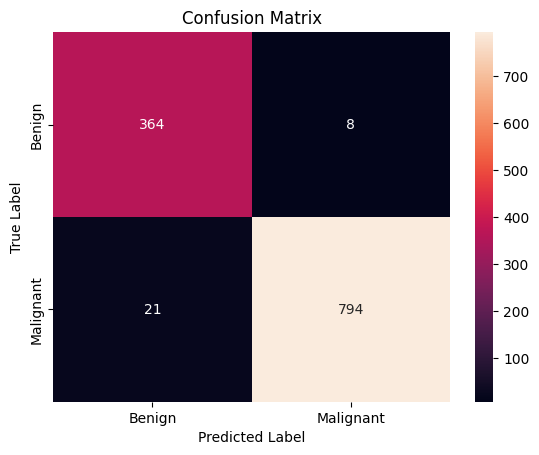

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0.5, 1.5], ["Benign", "Malignant"])
plt.yticks([0.5, 1.5], ["Benign", "Malignant"])
plt.show()

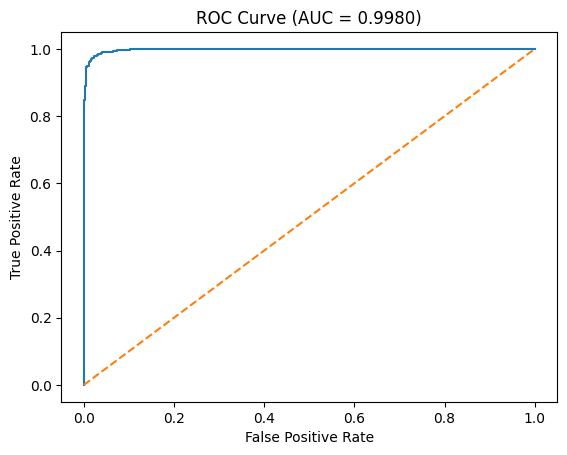

In [49]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curve (AUC = {auroc:.4f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

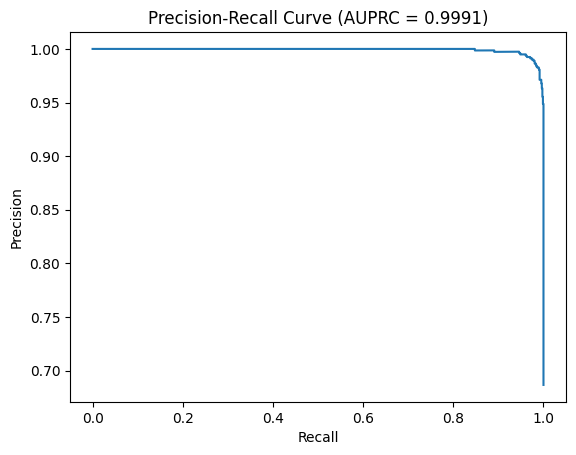

In [50]:
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_probs)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.title(f"Precision-Recall Curve (AUPRC = {auprc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [51]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity (Recall)",
        "Specificity",
        "F1-score",
        "AUROC",
        "AUPRC",
        "MCC",
        "Balanced Accuracy"
    ],
    "Score": [
        accuracy,
        precision,
        sensitivity,
        specificity,
        f1,
        auroc,
        auprc,
        mcc,
        balanced_acc
    ]
})

results

,Metric,Score
0,Accuracy,0.975569
1,Precision,0.990025
2,Sensitivity (Recall),0.974233
3,Specificity,0.978495
4,F1-score,0.982066
5,AUROC,0.997981
6,AUPRC,0.999065
7,MCC,0.944064
8,Balanced Accuracy,0.976364
